In [77]:
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, tree_util
from functools import partial
from matplotlib import pyplot as plt
import diffrax as dif
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#Formulierung des Anfangswertproblems
f = lambda params, z, u: jnp.array([u[1], params[0] * u[0] + params[1] * jnp.sin(z)])

z0 = 0.
z1 = 40.
u0 = jnp.array([1., -0.5])
params = jnp.array([0.01, 0.505])

In [78]:
@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV2(params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(params, z0, dz, u0, f):
        k1 = dz * f(params, z0, u0)
        k2 = dz * f(params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1

    def rk4_step_scan(u, x):
        return rk4_step(params, x, dz, u, f), \
            rk4_step(params, x, dz, u, f)

    zs = jnp.linspace(z0, z1, n)
    _, uz = lax.scan(rk4_step_scan, u0, zs[:-1])
    uz = jnp.concatenate([jnp.array([u0]), uz], axis=0)

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol', 'max_steps']) 
def diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(steps=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=max_steps)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(ts=jnp.linspace(0, z1, n))
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

f_analytical = lambda z: jnp.cosh(0.1*z) - 0.5*jnp.sin(z)

def block_until_ready(pytree):
  return tree_util.tree_map(lambda x: x.block_until_ready(), pytree)

In [79]:
ns = [5, 10, 20, 50, 100, 200, 500, 750, 1000, 1500, 2000]

df_e = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

for n in ns:
    uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
    t = %timeit -o block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))

    abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
    abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
    abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

    df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)

df_e.to_string('results/benchmark_eigen3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

7.94 µs ± 76.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_55736\577438145.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


8.06 µs ± 30.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
8.41 µs ± 61 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.38 µs ± 41.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
11.2 µs ± 31.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
14.6 µs ± 40.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
24.7 µs ± 759 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
32.9 µs ± 215 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
40.9 µs ± 219 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
58.3 µs ± 50 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
75.6 µs ± 816 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


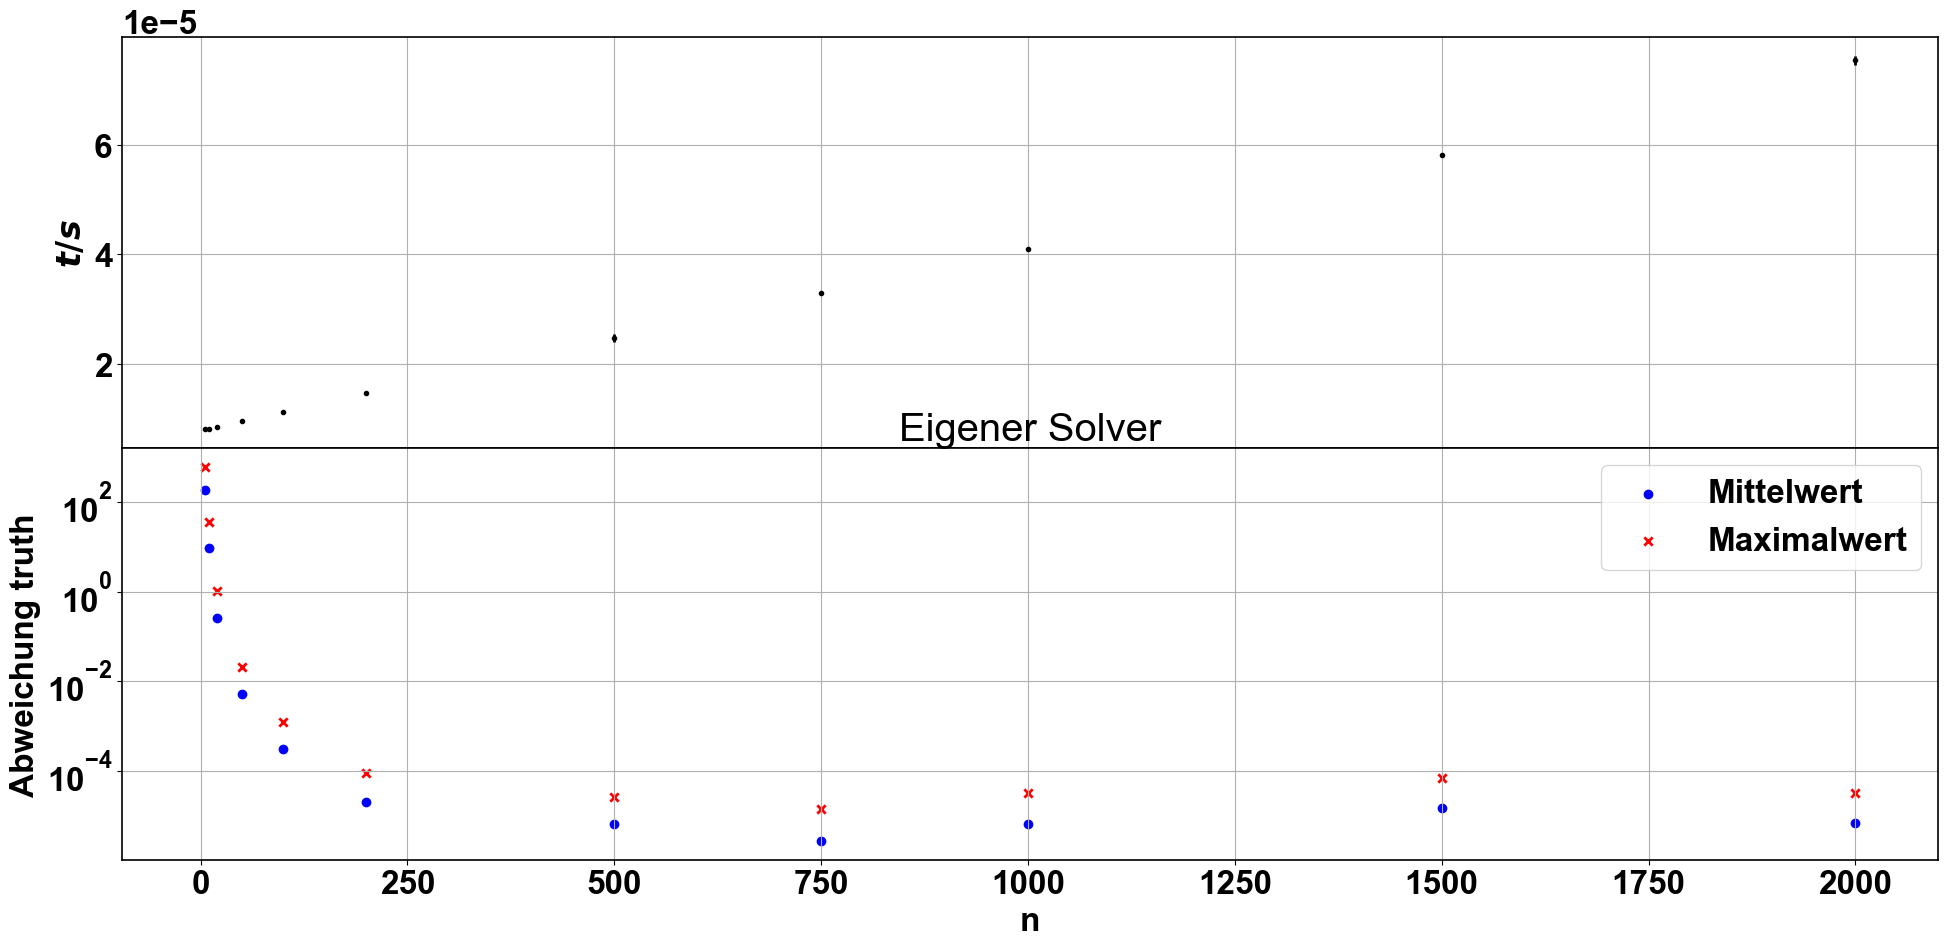

In [80]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Eigener Solver')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_e['n'], df_e['t_mean'], yerr=df_e['t_std'], color='black', fmt = '.')
ax[0].grid()
#ax[1].set_xscale('log')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_e['n'], df_e['abw_mean_eigen'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_e['n'], df_e['abw_max_eigen'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_eigen3.png')

In [81]:
rtol = 0
atols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10]

df_da = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for atol in atols:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_da = pd.concat([df_da, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_da.to_string('results/benchmark_dopria3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)


185 µs ± 788 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_55736\539210683.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_da = pd.concat([df_da, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


187 µs ± 753 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
189 µs ± 712 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
191 µs ± 1.11 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
196 µs ± 403 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
201 µs ± 1.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
210 µs ± 2.23 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
223 µs ± 2.13 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
269 µs ± 3.45 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
789 µs ± 11.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


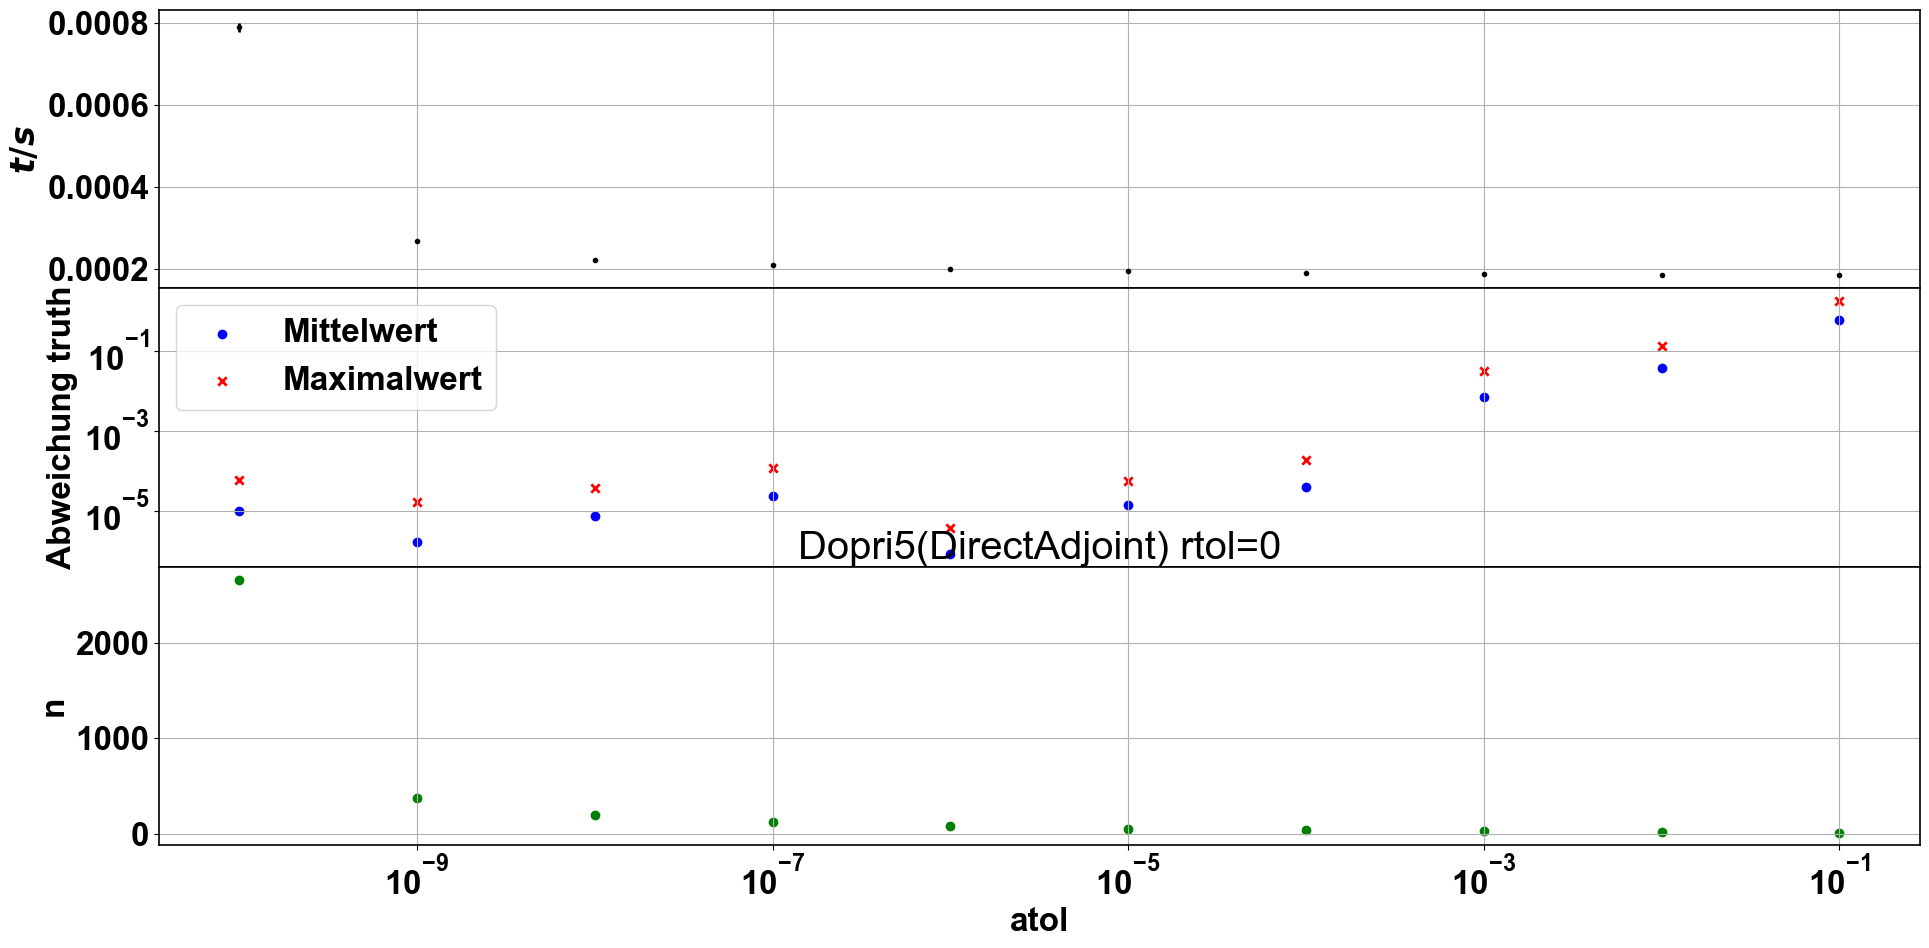

In [82]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_da['atol'], df_da['t_mean'], yerr=df_da['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_da['atol'], df_da['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_da['atol'], df_da['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('atol')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_da['atol'], df_da['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_dopria3.png')

In [83]:
ns = [5, 10, 50, 100, 500, 1000, 2000]
rtol = 0
atol = 1e-6

df_dn = pd.DataFrame(columns=['abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for n in ns:
    uz_doprin, zs_doprin = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol))

    abw_doprin = jnp.array([uz_doprin[i,0] - f_analytical(zs_doprin[i]) for i in range(n)])
    abw_mean_doprin = jnp.mean(jnp.abs(abw_doprin))
    abw_max_doprin = jnp.max(jnp.abs(abw_doprin))

    df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_dn.to_string('results/benchmark_doprin3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

189 µs ± 651 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_55736\2619236814.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


188 µs ± 1.27 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
192 µs ± 2.18 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
192 µs ± 836 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
194 µs ± 978 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
200 µs ± 1.33 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
211 µs ± 9.39 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


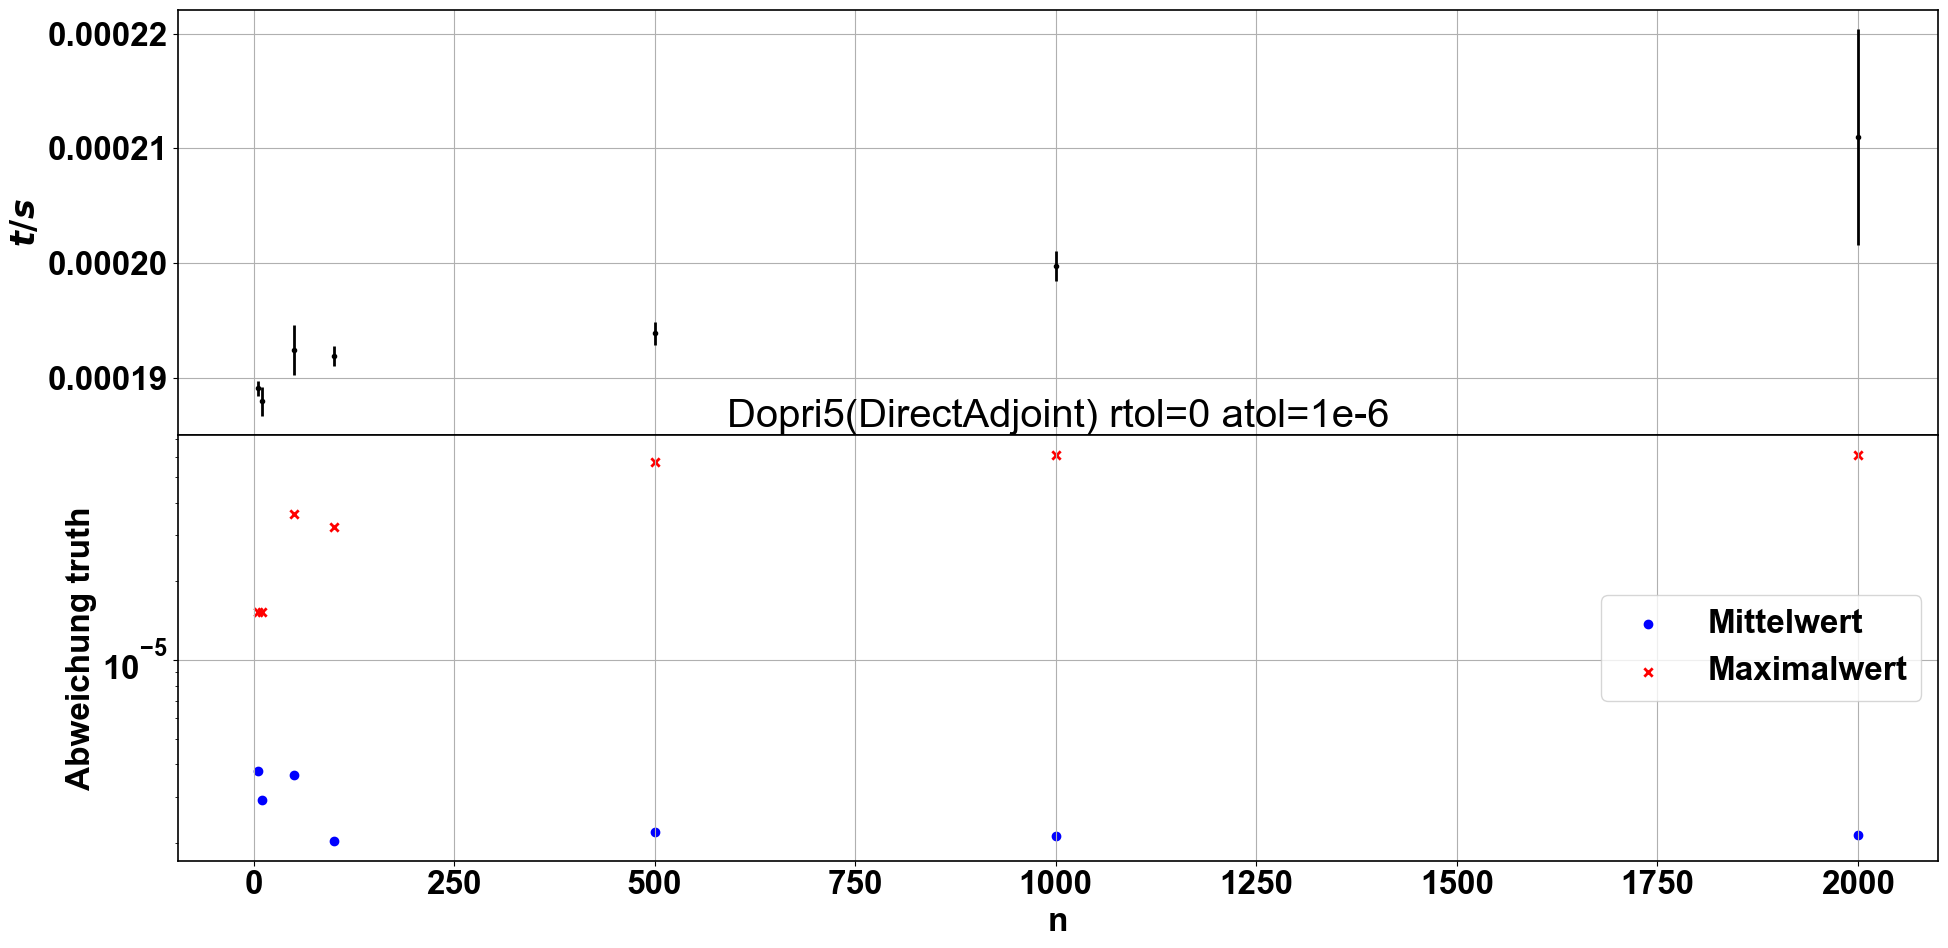

In [84]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0 atol=1e-6')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_dn['n'], df_dn['t_mean'], yerr=df_dn['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_dn['n'], df_dn['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_dn['n'], df_dn['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel('n')
#ax[1].set_xscale('log')
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('results/benchmark_doprin3.png')

In [93]:
rtols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
atol = 0

df_dr = pd.DataFrame(columns=['rtol', 'rel_abw_mean_dopri', 'rel_abw_max_dopri', 'n', 't_mean', 't_std'])

for rtol in rtols:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, 4096))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    rel_abw_dopri = jnp.array([(uz_dopri[i,0] - f_analytical(zs_dopri[i]) )/f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    rel_abw_mean_dopri = jnp.mean(jnp.abs(rel_abw_dopri))
    rel_abw_max_dopri = jnp.max(jnp.abs(rel_abw_dopri))

    df_dr = pd.concat([df_dr, pd.DataFrame({'rtol':[rtol], 'rel_abw_mean_dopri': [rel_abw_mean_dopri], 'rel_abw_max_dopri': [rel_abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_dr.to_string('results/benchmark_doprir3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

177 µs ± 1.02 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_55736\2272732318.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dr = pd.concat([df_dr, pd.DataFrame({'rtol':[rtol], 'rel_abw_mean_dopri': [rel_abw_mean_dopri], 'rel_abw_max_dopri': [rel_abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


177 µs ± 295 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
179 µs ± 2.77 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
179 µs ± 645 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
182 µs ± 894 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
186 µs ± 653 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
196 µs ± 567 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
221 µs ± 11.5 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
418 µs ± 2.17 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


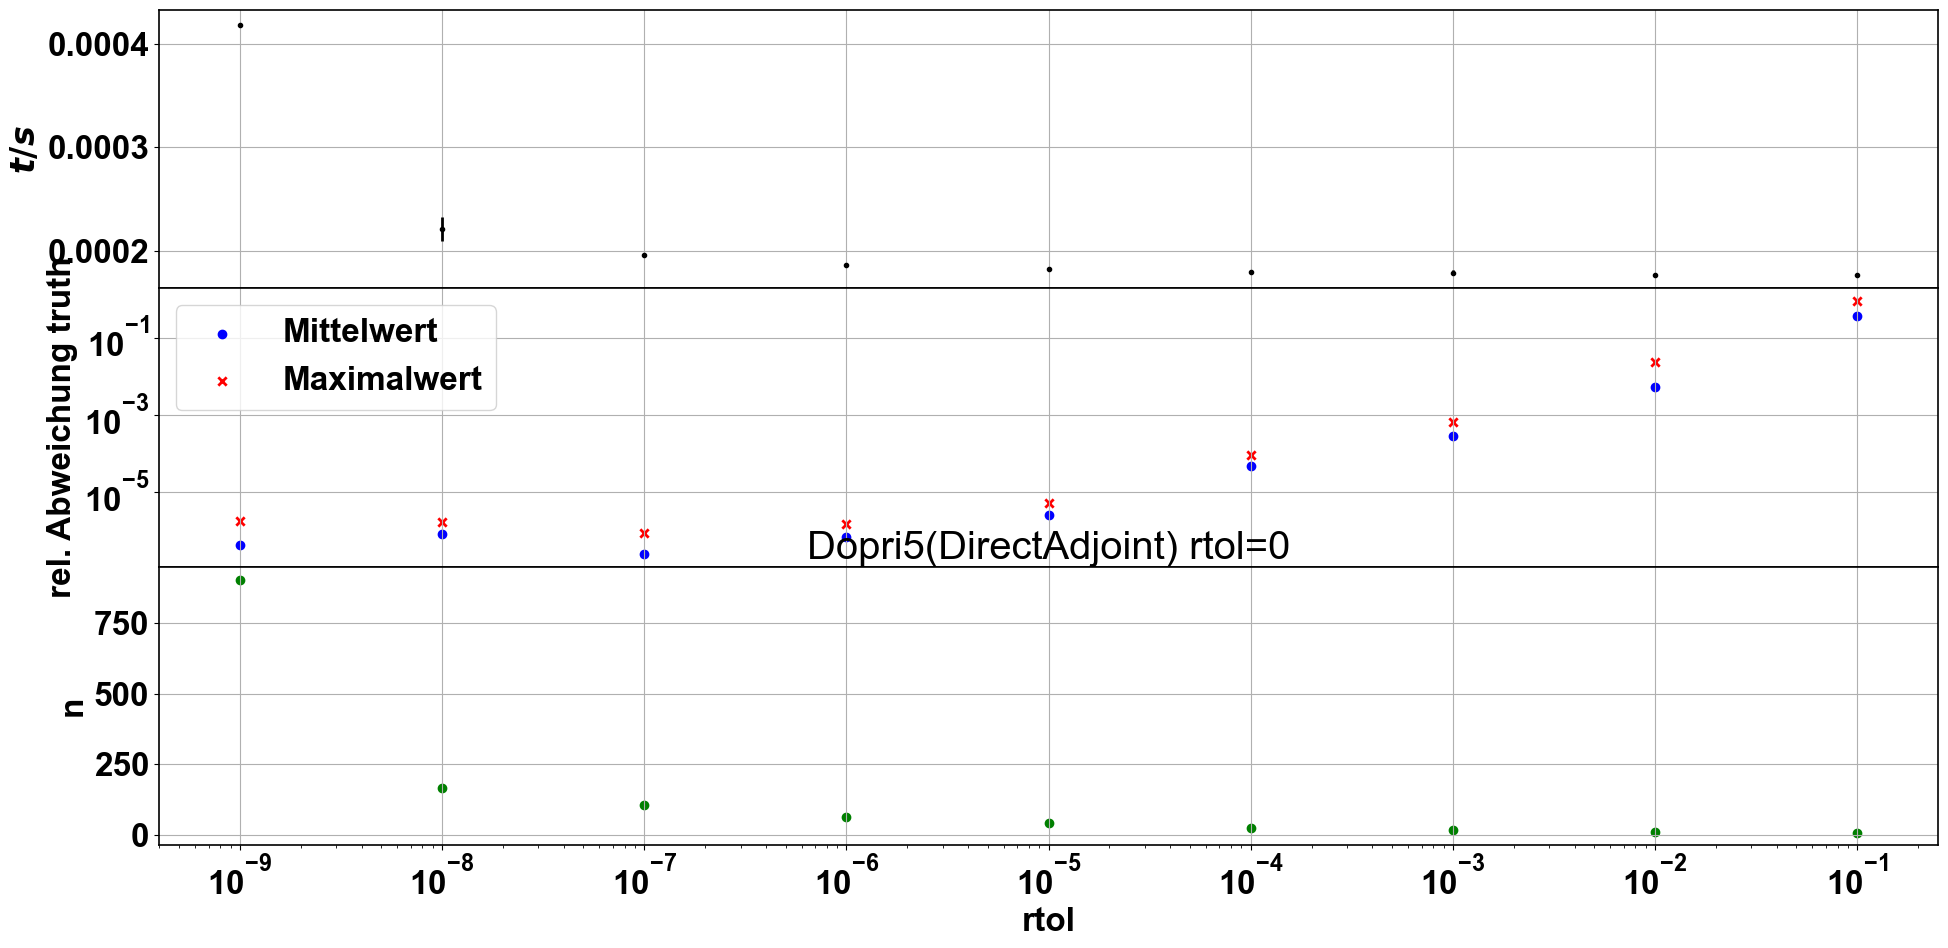

In [94]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_dr['rtol'], df_dr['t_mean'], yerr=df_dr['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('rel. Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_dr['rtol'], df_dr['rel_abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('rtol')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_dr['rtol'], df_dr['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [98]:
rtol = 0
atol = 1e-6
max_steps_ = [256, 4096, 65635, 1048576, 16777216]


df_ds = pd.DataFrame(columns=['max_steps', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for max_steps in max_steps_:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol, max_steps))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_ds.to_string('results/benchmark_dopris3.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

188 µs ± 1.98 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_55736\4255799064.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ds = pd.concat([df_ds, pd.DataFrame({'max_steps':[max_steps], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


193 µs ± 1.72 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
306 µs ± 1.58 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.16 ms ± 69.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
16 ms ± 462 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


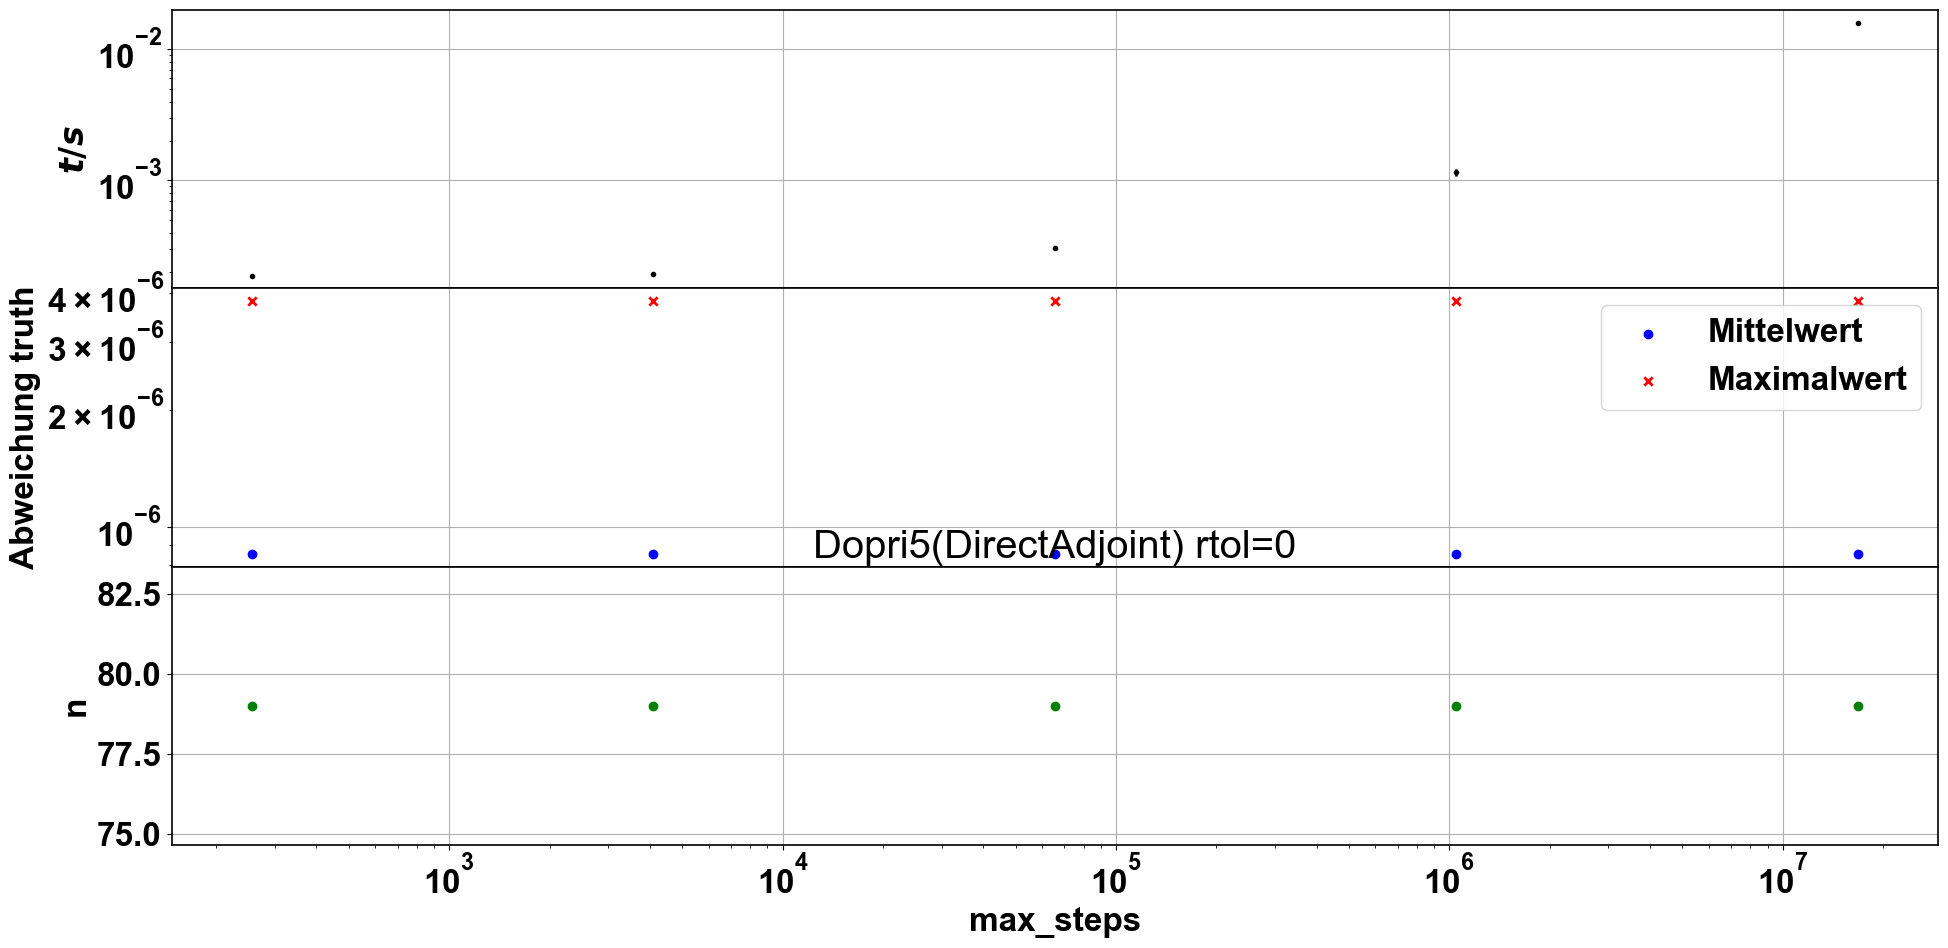

In [100]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
ax[0].set_yscale('log')
ax[0].errorbar(df_ds['max_steps'], df_ds['t_mean'], yerr=df_ds['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_ds['max_steps'], df_ds['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_ds['max_steps'], df_ds['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('max_steps')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_ds['max_steps'], df_ds['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)